In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2023-01-01
Revised on 2026-04-04

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — toolbox vignette, R to Python (_r2p)
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Chi-Square and t-Distribution Q-Q Plots and Tests — Toolbox Vignette (_r2p)
============================================================================

Purpose:
    Demonstrates how Chi-Square and t-distributions approach Normality
    as degrees of freedom (DF) increase.

    For N=30 observations and DF = 1 to N-1 = 29:
      - Draw samples from Chi-Square(DF) and t(DF)
      - Run Shapiro-Wilk normality test per sample
      - Run 100 trials per DF — store all p-values
      - Q-Q plots for the last trial at each DF
      - Boxplots of p-values vs. DF — visualize the DF impact

    Hypothesis testing:
      H0: data are normally distributed
      HA: data are NOT normally distributed
      p-value < 0.05 → reject H0 (not Normal)
      p-value > 0.05 → keep H0 (plausibly Normal)

    Key findings:
      Chi-Square: needs DF >= 20 for consistent normality (N=30)
      t-distribution: needs DF >= 6 for consistent normality (N=30)

    R equivalent: chsq_and_t_dist_q-q_plots_df_tests_vignette.Rmd
    R libraries:  base R (rchisq, rt, shapiro.test, qqnorm, qqline, boxplot)
    Python libs:  numpy, pandas, matplotlib, scipy.stats, statsmodels

    Suffix _r2p: This notebook was converted from R to Python.

Revision History:
    2023-01-01  Original R development (Harvard Elements of Statistical Learning)
                - R script: chsq_and_t_dist_q-q_plots_df_tests_vignette.Rmd

    2026-04-04  Converted to Python / Jupyter Notebook (_r2p)
                - rchisq(N, df) → rng.chisquare(df, N)
                - rt(N, df) → rng.standard_t(df, N)
                - shapiro.test() → scipy.stats.shapiro()
                - qqnorm() + qqline() → statsmodels.api.qqplot()
                - boxplot(p_value~deg_of_freedom) → seaborn.boxplot()
                - abline(v=20, h=0.05) → ax.axvline + ax.axhline
                - LaTeX $H_0$ notation used throughout (font-safe)
"""

'\nCreated on 2023-01-01\nRevised on 2026-04-04\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — toolbox vignette, R to Python (_r2p)\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nChi-Square and t-Distribution Q-Q Plots and Tests — Toolbox Vignette (_r2p)\n============================================================================\n\nPurpose:\n    Demonstrates how Chi-Square and t-distributions approach Normality\n    as degrees of freedom (DF) increase.\n\n    For N=30 observations and DF = 1 to N-1 = 29:\n      - Draw samples from Chi-Square(DF) and t(DF)\n      - Run Shapiro-Wilk normality test per sample\n      - Run 100 trials per DF — store all p-values\n      - Q-Q plots for the last trial at each DF\n      - Boxplots of p-values vs. DF — visualize the DF impact\n\n    Hypothesis testing:\n      H0: data are normally distributed\n      HA: data are NOT normally distr

# Chi-Square and t-Distribution Q-Q Plots and Tests — Toolbox Vignette

## Purpose

Demonstrates how **Chi-Square** and **t-distributions** approach Normality
as degrees of freedom (DF) increase.

**Hypothesis testing (Shapiro-Wilk):**
- $H_0$: data are normally distributed
- $H_A$: data are NOT normally distributed
- p-value < 0.05 → reject $H_0$ (not Normal)
- p-value > 0.05 → keep $H_0$ (plausibly Normal)

**Key question:** *Approximately how large must the degrees of freedom be,
for each distribution, to obtain a consistently Normal shape with N=30?*

**R equivalent:** `chsq_and_t_dist_q-q_plots_df_tests_vignette.Rmd`

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')

# Harvard color palette
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'

print('Imports complete.')

Imports complete.


---

## Simulate and Test: Q-Q Plots Across Degrees of Freedom

Mirrors R:
```r
N <- 30; Max_D <- N-1; TRIALS <- 100
for (i in 1:Max_D) {
  for (j in 1:TRIALS) {
    CHI_SAMPLE  <- rchisq(N, i);  CHI_SHAPIRO  <- shapiro.test(CHI_SAMPLE)
    T_SAMPLE    <- rt(N, i);      T_SHAPIRO    <- shapiro.test(T_SAMPLE)
  }
  qqnorm(CHI_SAMPLE, ...); qqline(CHI_SAMPLE, col='red')
  qqnorm(T_SAMPLE,   ...); qqline(T_SAMPLE,   col='red')
}
```

For each DF from 1 to N-1=29:
- Run 100 trials, store all Shapiro-Wilk p-values
- Q-Q plot the **last trial** at each DF (mirrors R behavior)

**Note:** The 5×4 Q-Q grid (29 DF × 2 distributions = 58 panels) is large.
We show a representative **subset** (DF = 1, 2, 4, 6, 10, 15, 20, 25, 29)
for readability, then plot **all DF** in the boxplot section.

In [3]:
# Parameters — mirrors R
N      = 30
Max_D  = N - 1   # 29
TRIALS = 100
rng    = np.random.default_rng(seed=42)

# Storage — mirrors R: chi_p.value and t_p.value dataframes
records = []

# Last-trial samples for Q-Q plots — mirrors R: CHI_SAMPLE, T_SAMPLE after inner loop
chi_last = {}   # df -> last CHI_SAMPLE array
t_last   = {}   # df -> last T_SAMPLE array
chi_p_last = {} # df -> last CHI_SHAPIRO p-value
t_p_last   = {} # df -> last T_SHAPIRO p-value

# Main loop — mirrors R: for (i in 1:Max_D) { for (j in 1:TRIALS) { ... } }
for df in range(1, Max_D + 1):
    for trial in range(TRIALS):
        # Chi-Square sample — mirrors R: rchisq(N, i)
        chi_sample  = rng.chisquare(df=df, size=N)
        chi_stat, chi_p = stats.shapiro(chi_sample)

        # t-distribution sample — mirrors R: rt(N, i)
        t_sample    = rng.standard_t(df=df, size=N)
        t_stat, t_p = stats.shapiro(t_sample)

        records.append({'deg_of_freedom': df, 'p_value': chi_p, 'distribution': 'chisq'})
        records.append({'deg_of_freedom': df, 'p_value': t_p,   'distribution': 't'})

    # Store last trial — mirrors R behavior (Q-Q plots last CHI_SAMPLE / T_SAMPLE)
    chi_last[df]   = chi_sample
    t_last[df]     = t_sample
    chi_p_last[df] = chi_p
    t_p_last[df]   = t_p

# Build DataFrame — mirrors R: chi_p.value, t_p.value
df_results = pd.DataFrame(records)

print(f'Simulation complete.')
print(f'  DF range   : 1 to {Max_D}')
print(f'  Trials/DF  : {TRIALS}')
print(f'  Total rows : {len(df_results)}  (2 distributions × {Max_D} DFs × {TRIALS} trials)')

Simulation complete.
  DF range   : 1 to 29
  Trials/DF  : 100
  Total rows : 5800  (2 distributions × 29 DFs × 100 trials)


## Q-Q Plots — Representative Subset of Degrees of Freedom

Mirrors R: `par(mfrow=c(5,4))` Q-Q grid.
Showing DF = 1, 2, 4, 6, 10, 15, 20, 25, 29 (9 values × 2 distributions = 18 panels).

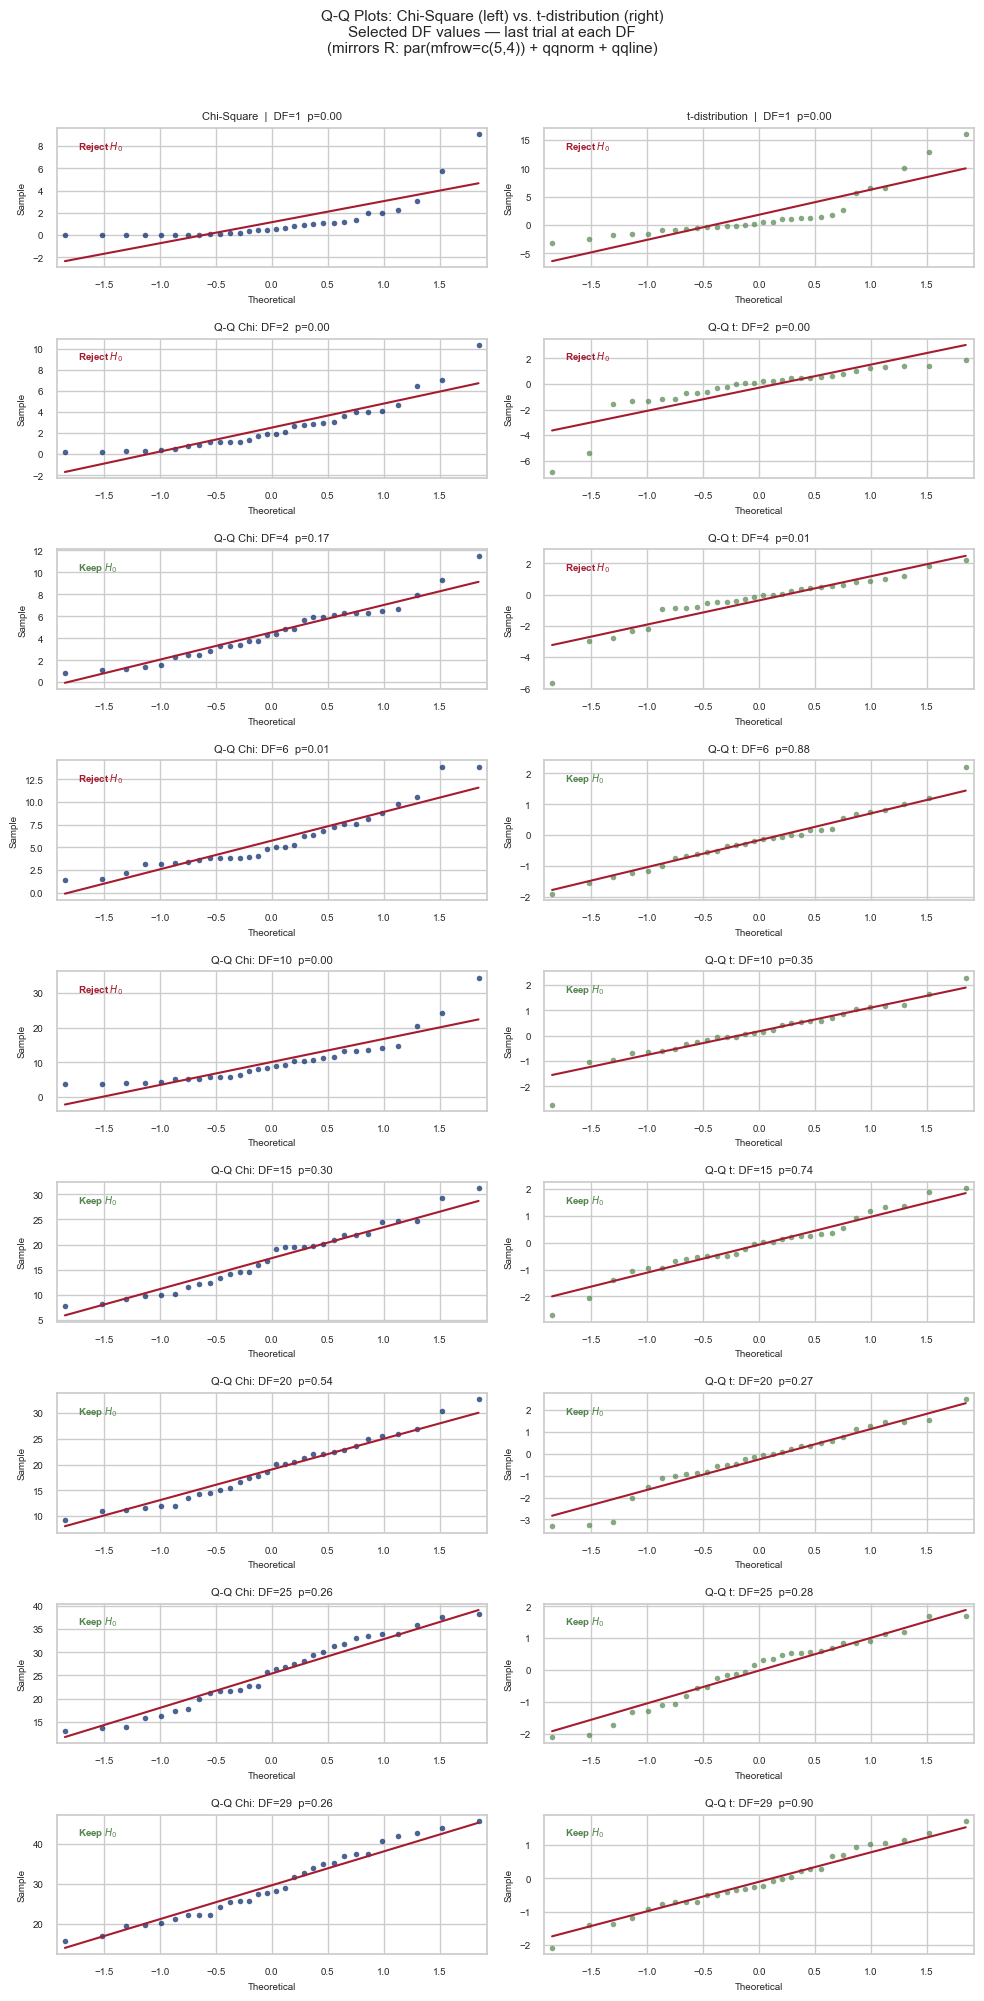

In [4]:
# Representative DF values — mirrors R's 5x4 grid intent
df_show = [1, 2, 4, 6, 10, 15, 20, 25, 29]
n_show  = len(df_show)

fig, axes = plt.subplots(n_show, 2, figsize=(10, n_show * 2.2))

for row, df_val in enumerate(df_show):
    # --- Chi-Square Q-Q ---
    # mirrors R: qqnorm(CHI_SAMPLE, col='blue') + qqline(col='red')
    ax_chi = axes[row, 0]
    sm.qqplot(chi_last[df_val], line='s', ax=ax_chi,
              marker='o', markerfacecolor=ROYALBLUE,
              markeredgecolor='none', markersize=4, alpha=0.7)
    for line in ax_chi.get_lines():
        line.set_color(CRIMSON); line.set_linewidth(1.5)
    ax_chi.set_title(f'Q-Q Chi: DF={df_val}  p={chi_p_last[df_val]:.2f}',
                     fontsize=8)
    ax_chi.set_xlabel('Theoretical', fontsize=7)
    ax_chi.set_ylabel('Sample', fontsize=7)
    ax_chi.tick_params(labelsize=7)
    decision_chi = r'Keep $H_0$' if chi_p_last[df_val] > 0.05 else r'Reject $H_0$'
    color_chi    = IVY if chi_p_last[df_val] > 0.05 else CRIMSON
    ax_chi.text(0.05, 0.85, decision_chi, transform=ax_chi.transAxes,
                color=color_chi, fontsize=7, fontweight='bold')

    # --- t-distribution Q-Q ---
    # mirrors R: qqnorm(T_SAMPLE, col='green') + qqline(col='red')
    ax_t = axes[row, 1]
    sm.qqplot(t_last[df_val], line='s', ax=ax_t,
              marker='o', markerfacecolor=IVY,
              markeredgecolor='none', markersize=4, alpha=0.7)
    for line in ax_t.get_lines():
        line.set_color(CRIMSON); line.set_linewidth(1.5)
    ax_t.set_title(f'Q-Q t: DF={df_val}  p={t_p_last[df_val]:.2f}',
                   fontsize=8)
    ax_t.set_xlabel('Theoretical', fontsize=7)
    ax_t.set_ylabel('Sample', fontsize=7)
    ax_t.tick_params(labelsize=7)
    decision_t = r'Keep $H_0$' if t_p_last[df_val] > 0.05 else r'Reject $H_0$'
    color_t    = IVY if t_p_last[df_val] > 0.05 else CRIMSON
    ax_t.text(0.05, 0.85, decision_t, transform=ax_t.transAxes,
              color=color_t, fontsize=7, fontweight='bold')

# Column headers
axes[0, 0].set_title(f'Chi-Square  |  DF=1  p={chi_p_last[1]:.2f}', fontsize=8)
axes[0, 1].set_title(f't-distribution  |  DF=1  p={t_p_last[1]:.2f}', fontsize=8)

fig.suptitle('Q-Q Plots: Chi-Square (left) vs. t-distribution (right)\n'
             'Selected DF values — last trial at each DF\n'
             '(mirrors R: par(mfrow=c(5,4)) + qqnorm + qqline)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

---

## Boxplot: Visualize DF Impact on Normality p-values

Mirrors R:
```r
par(mfrow=c(1,2))
boxplot(p_value~deg_of_freedom, chi_p.value, col='lightblue', ...)
abline(v=20, h=0.05, col='red')
boxplot(p_value~deg_of_freedom, t_p.value,   col='lightgreen', ...)
abline(v=6,  h=0.05, col='red')
```

100 Shapiro-Wilk p-values per DF, boxplotted.
The red lines mark the key thresholds:
- Horizontal: p=0.05 (normality threshold)
- Vertical: DF where IQR consistently clears p=0.05
  (Chi-Square: DF≈20, t: DF≈6)

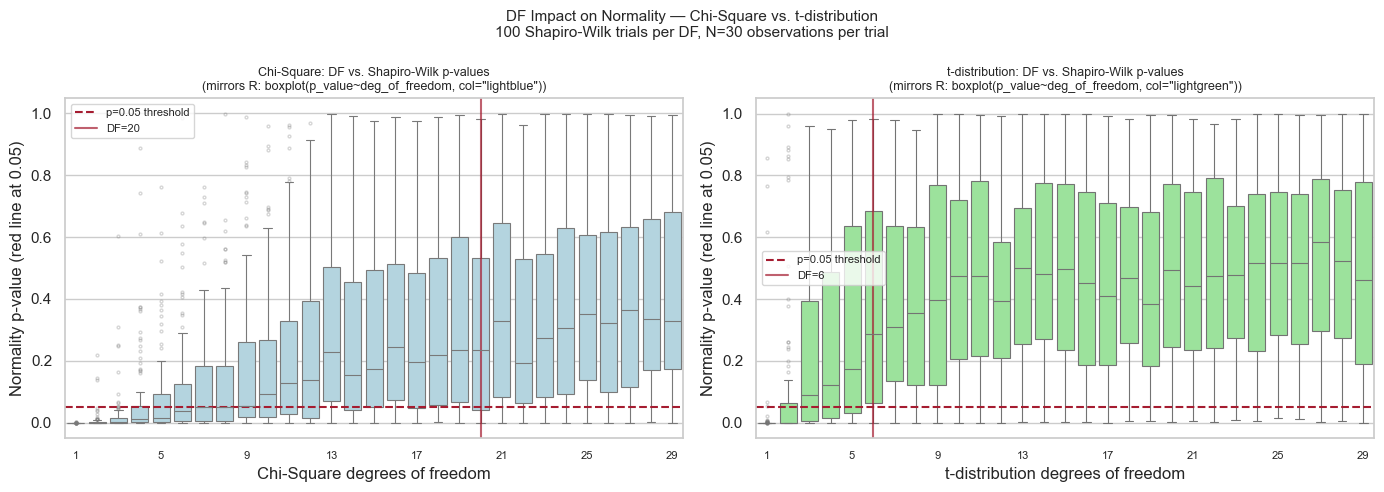

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chi-Square boxplot ---
# mirrors R: boxplot(p_value~deg_of_freedom, chi_p.value, col='lightblue')
chi_df = df_results[df_results['distribution'] == 'chisq'].copy()
chi_df['deg_of_freedom'] = chi_df['deg_of_freedom'].astype(int)

sns.boxplot(data=chi_df, x='deg_of_freedom', y='p_value',
            ax=axes[0], color='lightblue', linewidth=0.8,
            fliersize=2, flierprops=dict(alpha=0.3))

# abline(h=0.05) — normality threshold
axes[0].axhline(0.05, color=CRIMSON, linewidth=1.5,
                linestyle='--', label='p=0.05 threshold')
# abline(v=20) — mirrors R: vertical at DF=20
# x-axis is categorical (0-indexed), DF=20 is at index 19
axes[0].axvline(19, color=CRIMSON, linewidth=1.5,
                linestyle='-', alpha=0.7, label='DF=20')

axes[0].set_title('Chi-Square: DF vs. Shapiro-Wilk p-values\n'
                  '(mirrors R: boxplot(p_value~deg_of_freedom, col="lightblue"))',
                  fontsize=9)
axes[0].set_xlabel('Chi-Square degrees of freedom')
axes[0].set_ylabel('Normality p-value (red line at 0.05)')
axes[0].set_xticks(range(0, Max_D, 4))
axes[0].set_xticklabels(range(1, Max_D + 1, 4), fontsize=8)
axes[0].legend(fontsize=8)

# --- t-distribution boxplot ---
# mirrors R: boxplot(p_value~deg_of_freedom, t_p.value, col='lightgreen')
t_df = df_results[df_results['distribution'] == 't'].copy()
t_df['deg_of_freedom'] = t_df['deg_of_freedom'].astype(int)

sns.boxplot(data=t_df, x='deg_of_freedom', y='p_value',
            ax=axes[1], color='lightgreen', linewidth=0.8,
            fliersize=2, flierprops=dict(alpha=0.3))

# abline(h=0.05)
axes[1].axhline(0.05, color=CRIMSON, linewidth=1.5,
                linestyle='--', label='p=0.05 threshold')
# abline(v=6) — mirrors R: vertical at DF=6
axes[1].axvline(5, color=CRIMSON, linewidth=1.5,
                linestyle='-', alpha=0.7, label='DF=6')

axes[1].set_title('t-distribution: DF vs. Shapiro-Wilk p-values\n'
                  '(mirrors R: boxplot(p_value~deg_of_freedom, col="lightgreen"))',
                  fontsize=9)
axes[1].set_xlabel('t-distribution degrees of freedom')
axes[1].set_ylabel('Normality p-value (red line at 0.05)')
axes[1].set_xticks(range(0, Max_D, 4))
axes[1].set_xticklabels(range(1, Max_D + 1, 4), fontsize=8)
axes[1].legend(fontsize=8)

fig.suptitle('DF Impact on Normality — Chi-Square vs. t-distribution\n'
             f'100 Shapiro-Wilk trials per DF, N={N} observations per trial',
             fontsize=11)
plt.tight_layout()
plt.show()

**Takeaways** (from original R vignette):

- Both Chi-Square and t-distributions approach Normality as DF increases — visible in Q-Q alignment and rising p-values.
- The t-distribution converges **faster**: IQR of p-values clears 0.05 at **DF ≈ 6**.
- The Chi-Square distribution converges **slower**: IQR clears 0.05 at **DF ≈ 20**.
- This is consistent with theory: Chi-Square is right-skewed at low DF; t is symmetric (heavier tails) but converges to Normal more quickly.
- The upward trend in both boxplot charts confirms the CLT: more DF → more Normal.

---

## Median p-value by DF — Summary Table

In [6]:
# Summary table — median p-value per DF for each distribution
summary = (df_results
           .groupby(['distribution', 'deg_of_freedom'])['p_value']
           .agg(['median', 'mean'])
           .round(4)
           .reset_index())

# Show key DF values
key_dfs = [1, 2, 4, 6, 10, 15, 20, 25, 29]
print('Median Shapiro-Wilk p-value by DF (key values):')
print(summary[summary['deg_of_freedom'].isin(key_dfs)]
      .pivot(index='deg_of_freedom', columns='distribution',
             values='median')
      .rename(columns={'chisq': 'Chi-Square (median p)',
                        't'    : 't-dist (median p)'})
      .to_string())
print()
print('Vertical red line guidelines (from R analysis):')
print('  Chi-Square  : DF >= 20 for consistent IQR above p=0.05')
print('  t-distribution: DF >= 6 for consistent IQR above p=0.05')

Median Shapiro-Wilk p-value by DF (key values):
distribution    Chi-Square (median p)  t-dist (median p)
deg_of_freedom                                          
1                              0.0000             0.0000
2                              0.0004             0.0003
4                              0.0104             0.1211
6                              0.0391             0.2871
10                             0.0932             0.4754
15                             0.1722             0.4979
20                             0.2342             0.4950
25                             0.3499             0.5157
29                             0.3278             0.4623

Vertical red line guidelines (from R analysis):
  Chi-Square  : DF >= 20 for consistent IQR above p=0.05
  t-distribution: DF >= 6 for consistent IQR above p=0.05


---

# Summary

## Key Takeaways

1. **Chi-Square(DF)** is right-skewed at low DF and approaches Normal slowly.
   With N=30, consistent normality (IQR of p-values above 0.05) requires **DF ≥ 20**.

2. **t(DF)** is symmetric but heavy-tailed at low DF. It approaches Normal
   much faster — consistent normality with **DF ≥ 6** for N=30.

3. **The threshold depends on use case:** stricter applications may require
   higher DF. The boxplot IQR guideline (not just median) is the conservative choice.

4. **100 trials per DF** removes the noise of single-trial inference.
   A single Q-Q plot at any DF can look Normal or non-Normal by chance;
   the boxplot of 100 p-values reveals the true underlying trend.

## R → Python Mapping

| R | Python |
|---|--------|
| `rchisq(N, df)` | `rng.chisquare(df=df, size=N)` |
| `rt(N, df)` | `rng.standard_t(df=df, size=N)` |
| `shapiro.test(x)` | `scipy.stats.shapiro(x)` |
| `shapiro.test(x)$p.value` | `stats.shapiro(x)[1]` |
| `qqnorm(x, col='blue')` + `qqline(col='red')` | `sm.qqplot(x, line='s', ax=ax)` |
| `boxplot(p~df, data, col='lightblue')` | `sns.boxplot(data=df, x='df', y='p', color='lightblue')` |
| `abline(h=0.05, col='red')` | `ax.axhline(0.05, color=CRIMSON)` |
| `abline(v=20, col='red')` | `ax.axvline(19, color=CRIMSON)` (0-indexed) |
| `par(mfrow=c(5,4))` | `plt.subplots(n_show, 2)` |
| `as.data.frame(matrix(NA,...))` | `pd.DataFrame(records)` via list of dicts |
| `$H_0$` (LaTeX in R) | `r'$H_0$'` (raw string in matplotlib) |

## References

1. Harvard Elements of Statistical Learning (2021),
   Dr. Andrey Sivachenko and Dr. Victor A. Farutin.
2. Gareth James, et al. *An Introduction to Statistical Learning
   with Applications in R*. Springer. ISBN 978-1-4614-7137-0.
3. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J.
   *An Introduction to Statistical Learning with Applications in Python*.
   Springer, 2023. https://www.statlearning.com